In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. DOWNLOAD DATA
# use 'NVDA' (Nvidia) because it has high volatility, making trends easy to see.
# you can use other stocks or assets

ticker = 'NVDA' 
start_date = '2020-01-01'
end_date = '2025-12-31'

def download_data(ticker, start_date, end_date):
    """Download historical price data for the specified ticker."""
    print(f"Downloading data for {ticker}...")
    try:
        df = yf.download(ticker, start=start_date, end=end_date)
        print(f"Downloaded {len(df)} rows of data for {ticker}")

        # Drop any rows with missing values to prevent errors later
        print(f"Checking for NA values...")
        df = df.dropna()
        print(f"Data filtered. {len(df)} rows of data remaining for {ticker}")



        return df
    except Exception as e:
        print(f"Error downloading data: {e}")
        return None

def load_and_prepare_data(data_dir):
    return pd.read_csv(data_dir)

df = download_data(ticker, start_date, end_date) # or load_and_prepare_data("csv")

# Check if data looks correct (Open, High, Low, Close, Volume)
print(df.head())

[*********************100%***********************]  1 of 1 completed

Downloaded 1528 rows of data for UEN.F
Checking for NA values...
Data filtered. 1528 rows of data remaining for UEN.F
Price           Close       High        Low       Open Volume
Ticker          UEN.F      UEN.F      UEN.F      UEN.F  UEN.F
Date                                                         
2020-01-02  61.799999  61.799999  61.799999  61.799999     10
2020-01-03  62.000000  62.000000  62.000000  62.000000      0
2020-01-06  61.500000  62.000000  61.500000  62.000000    170
2020-01-07  63.240002  63.240002  61.840000  61.840000     52
2020-01-08  61.000000  61.000000  60.980000  60.980000    109


In [ ]:
# 2. IMPLEMENT STRATEGY
# Calculate Moving Averages
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# Create Signals (1 = Buy, 0 = Sell/Cash)
df['Signal'] = np.where(df['SMA_20'] > df['SMA_50'], 1.0, 0.0)

# CRITICAL STEP: Create 'Position'
# Shift the signal by 1 day. 
# Why? We calculate the signal using Today's Close price. 
# We can only buy at Tomorrow's Open. If we don't shift, it's "Look-ahead Bias" (cheating).
df['Position'] = df['Signal'].shift(1)

print("Strategy indicators created.")
df.to_csv("strategy.csv")
print(df.tail(5))

Strategy indicators created.
Price       Close   High    Low   Open Volume  SMA_10  SMA_20 Signal Position
Ticker      UEN.F  UEN.F  UEN.F  UEN.F  UEN.F                                
Date                                                                         
2025-12-19  6.340  6.444  6.106  6.106   2008  6.1654  6.4414    0.0      0.0
2025-12-22  6.322  6.422  6.300  6.304   2031  6.1854  6.3887    0.0      0.0
2025-12-23  6.298  6.350  6.298  6.300    965  6.2054  6.3608    0.0      0.0
2025-12-29  6.472  6.472  5.942  6.366    831  6.2448  6.3515    0.0      0.0
2025-12-30  6.520  6.520  6.290  6.290     31  6.2758  6.3485    0.0      0.0


In [ ]:
# 3. CALCULATE RETURNS
# Calculate daily percent change of the stock (Buy and Hold strategy)
df['Market_Return'] = df['Close'].pct_change() #(current - previous) / previous : rate of change of value

# Calculate Strategy Returns
# If Position was 1 yesterday, we get the Market_Return today.
# If Position was 0, we get 0 return.
df['Strategy_Return'] = df['Position'] * df['Market_Return']

# 4. CALCULATE METRICS
# Cumulative Returns (for plotting)
df['Cumulative_Market_Return'] = (1 + df['Market_Return']).cumprod()
df['Cumulative_Strategy_Return'] = (1 + df['Strategy_Return']).cumprod()

# Sharpe Ratio (Risk-Adjusted Return)
# Assume 252 trading days in a year. 
sharpe_ratio = (df['Strategy_Return'].mean() / df['Strategy_Return'].std()) * np.sqrt(252)

# Max Drawdown (Worst loss from a peak)
# Calculate running maximum
running_max = df['Cumulative_Strategy_Return'].cummax()
drawdown = (df['Cumulative_Strategy_Return'] / running_max) - 1
max_drawdown = drawdown.min()

print(f"--- Performance Metrics for {ticker} ---")
print(f"Total Market Return: {df['Cumulative_Market_Return'].iloc[-1]:.2f}x")
print(f"Total Strategy Return: {df['Cumulative_Strategy_Return'].iloc[-1]:.2f}x")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2%}")

--- Performance Metrics for UEN.F ---
Total Market Return: 0.11x
Total Strategy Return: 0.23x
Sharpe Ratio: -0.60
Max Drawdown: -78.78%


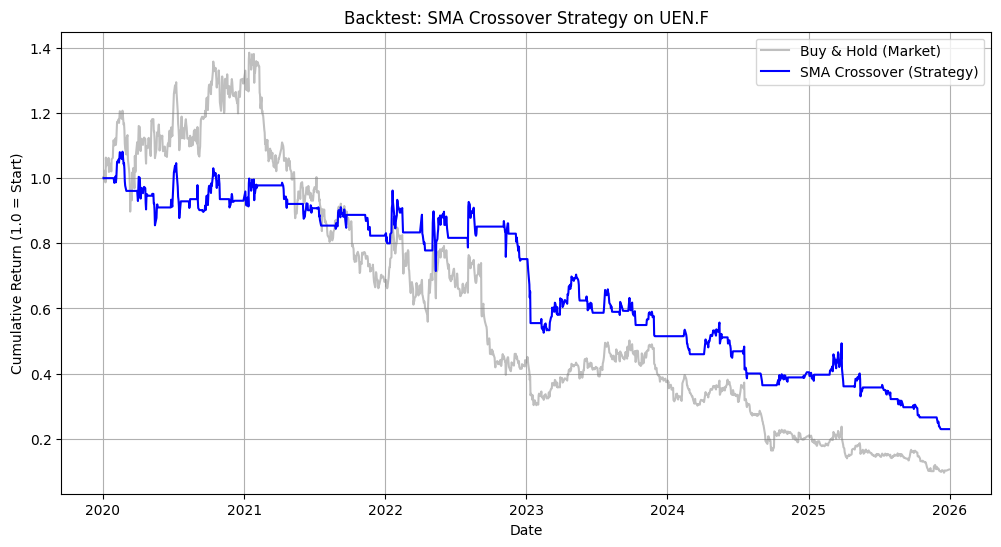

In [28]:
# 5. VISUALIZE
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Cumulative_Market_Return'], label='Buy & Hold (Market)', color='gray', alpha=0.5)
plt.plot(df.index, df['Cumulative_Strategy_Return'], label='SMA Crossover (Strategy)', color='blue')

plt.title(f'Backtest: SMA Crossover Strategy on {ticker}')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (1.0 = Start)')
plt.legend()
plt.grid(True)
plt.show()